In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import random
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


In [3]:
DATA_DIR = "/content/drive/MyDrive/Student AI Workspace/FaceClassifier/data"

IMAGE_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 10
NUM_CLASSES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [10]:
class FaceDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None, val_per_class=10):
        self.samples = []
        self.transform = transform

        class_folders = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])

        for label, folder in enumerate(class_folders):
            folder_path = os.path.join(root_dir, folder)
            images = sorted(os.listdir(folder_path))

            random.seed(42)
            random.shuffle(images)

            if split == "train":
                images = images[val_per_class:]
            else:
                images = images[:val_per_class]

            for img in images:
                self.samples.append(
                    (os.path.join(folder_path, img), label)
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [11]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [12]:
train_dataset = FaceDataset(
    DATA_DIR,
    split="train",
    transform=train_transform,
    val_per_class=10
)

val_dataset = FaceDataset(
    DATA_DIR,
    split="val",
    transform=val_transform,
    val_per_class=10
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


Train samples: 143
Val samples: 40


In [13]:
model = models.resnet18(pretrained=True)

# Freeze toàn bộ backbone
for param in model.parameters():
    param.requires_grad = False

# Thay fully connected layer cuối
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(DEVICE)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)


In [15]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [16]:
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )


Epoch [1/10] Train Loss: 1.1617 Val Acc: 0.8500
Epoch [2/10] Train Loss: 0.5947 Val Acc: 1.0000
Epoch [3/10] Train Loss: 0.3745 Val Acc: 1.0000
Epoch [4/10] Train Loss: 0.2925 Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.2089 Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.1676 Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.1505 Val Acc: 1.0000
Epoch [8/10] Train Loss: 0.1239 Val Acc: 1.0000
Epoch [9/10] Train Loss: 0.1138 Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.1429 Val Acc: 1.0000


In [17]:
torch.save(model.state_dict(), "resnet_face_classifier.pth")
print("Model saved")


Model saved


In [18]:
# In toàn bộ kiến trúc ResNet + classifier
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Class names: {0: 'son', 1: 'thang', 2: 'hieu', 3: 'loi'}
Confusion Matrix:
[[10  0  0  0]
 [ 0 10  0  0]
 [ 0  0 10  0]
 [ 0  0  0 10]]


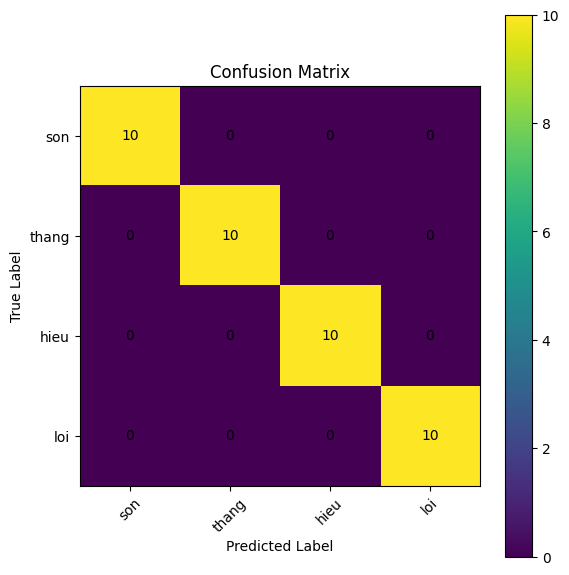

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load class names từ file
CLASS_NAMES_PATH = "/content/drive/MyDrive/Student AI Workspace/FaceClassifier/data/class_names.txt"

class_names = {}
with open(CLASS_NAMES_PATH, "r") as f:
    for line in f:
        idx, name = line.strip().split()
        class_names[int(idx)] = name

print("Class names:", class_names)


def compute_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm


def plot_confusion_matrix(cm, class_names):
    labels = [class_names[i] for i in range(len(class_names))]

    plt.figure(figsize=(6, 6))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()

    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


cm = compute_confusion_matrix(model, val_loader, DEVICE)

print("Confusion Matrix:")
print(cm)

plot_confusion_matrix(cm, class_names)


In [24]:
class_names = {0: "son", 1: "thang", 2: "hieu", 3: "loi"}

Saving anh test.jpg to anh test.jpg


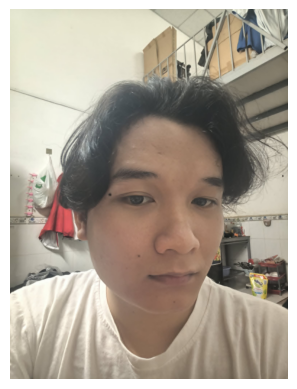

Predicted: son


In [26]:
from google.colab import files
from PIL import Image
import torch
import matplotlib.pyplot as plt

# Upload ảnh từ máy
uploaded = files.upload()

# Lấy file đầu tiên
image_path = list(uploaded.keys())[0]

# Load và hiển thị ảnh
image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

# Tiền xử lý ảnh
image_tensor = val_transform(image)
image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

# Dự đoán
with torch.no_grad():
    outputs = model(image_tensor)
    pred = torch.argmax(outputs, dim=1).item()

print("Predicted:", class_names[pred])
